# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [ ]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [ ]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [ ]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5], dtype=int64)

In [ ]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [ ]:
df.isnull().sum()

df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()  # 719 duplicate rows

df.drop_duplicates(inplace=True)

In [ ]:
unique_sales_channels = df["sales_channel"].unique()

print(unique_sales_channels)

['Internet' 'Mobile']


In [ ]:
unique_booking_origin = df["booking_origin"].unique()

print(unique_booking_origin)

['New Zealand' 'India' 'United Kingdom' 'China' 'South Korea' 'Japan'
 'Malaysia' 'Singapore' 'Switzerland' 'Germany' 'Indonesia'
 'Czech Republic' 'Vietnam' 'Thailand' 'Spain' 'Romania' 'Ireland' 'Italy'
 'Slovakia' 'United Arab Emirates' 'Tonga' 'Réunion' '(not set)'
 'Saudi Arabia' 'Netherlands' 'Qatar' 'Hong Kong' 'Philippines'
 'Sri Lanka' 'France' 'Croatia' 'United States' 'Laos' 'Hungary'
 'Portugal' 'Cyprus' 'Australia' 'Cambodia' 'Poland' 'Belgium' 'Oman'
 'Bangladesh' 'Kazakhstan' 'Brazil' 'Turkey' 'Kenya' 'Taiwan' 'Brunei'
 'Chile' 'Bulgaria' 'Ukraine' 'Denmark' 'Colombia' 'Iran' 'Bahrain'
 'Solomon Islands' 'Slovenia' 'Mauritius' 'Nepal' 'Russia' 'Kuwait'
 'Mexico' 'Sweden' 'Austria' 'Lebanon' 'Jordan' 'Greece' 'Mongolia'
 'Canada' 'Tanzania' 'Peru' 'Timor-Leste' 'Argentina' 'New Caledonia'
 'Macau' 'Myanmar (Burma)' 'Norway' 'Panama' 'Bhutan' 'Norfolk Island'
 'Finland' 'Nicaragua' 'Maldives' 'Egypt' 'Israel' 'Tunisia'
 'South Africa' 'Papua New Guinea' 'Paraguay' 'Estonia

In [ ]:
not_set_count = (df["booking_origin"] == "(not set)").sum()

not_set_count

78

In [ ]:
not_set = df.drop(df[df["booking_origin"] == "(not set)"].index)
display(not_set)

df = not_set

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,6,PERPNH,Australia,1,0,1,5.62,0
49996,1,Internet,RoundTrip,111,6,4,7,PERPNH,Australia,0,0,0,5.62,0
49997,1,Internet,RoundTrip,24,6,22,6,PERPNH,Australia,0,0,1,5.62,0
49998,1,Internet,RoundTrip,15,6,11,1,PERPNH,Australia,1,0,1,5.62,0


In [ ]:
df["trip_type"].unique()

array(['RoundTrip', 'CircleTrip', 'OneWay'], dtype=object)

In [ ]:
df["booking_id"] = range(1, len(df) + 1)

df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_id
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0,1
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0,2
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0,3
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0,4
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,6,PERPNH,Australia,1,0,1,5.62,0,49199
49996,1,Internet,RoundTrip,111,6,4,7,PERPNH,Australia,0,0,0,5.62,0,49200
49997,1,Internet,RoundTrip,24,6,22,6,PERPNH,Australia,0,0,1,5.62,0,49201
49998,1,Internet,RoundTrip,15,6,11,1,PERPNH,Australia,1,0,1,5.62,0,49202


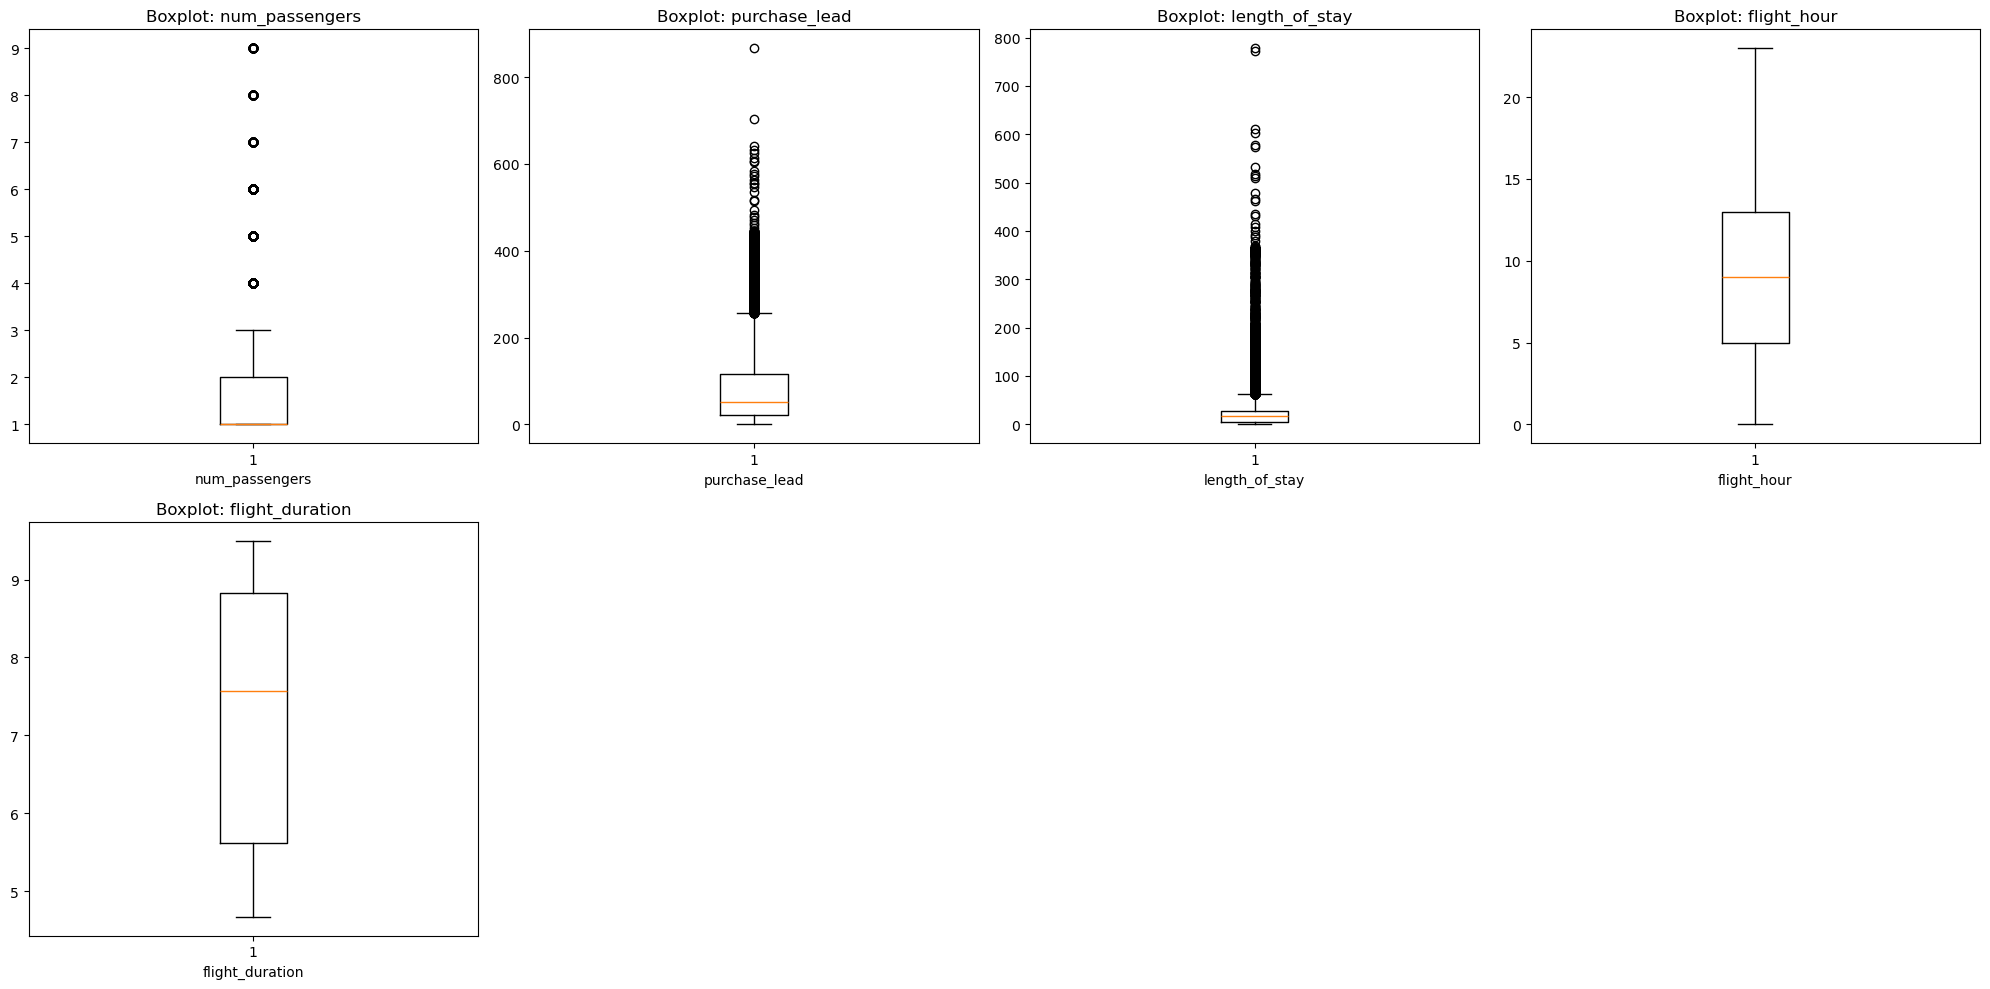

In [ ]:
import matplotlib.pyplot as plt

numerical_columns = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration",
]

fig, ax = plt.subplots(2, 4, figsize=(20, 10))

axs = ax.flatten()

for i, col in enumerate(numerical_columns):
    axs[i].boxplot(df[col])
    axs[i].set_xlabel(col)
    axs[i].set_title(f"Boxplot: {col}")

for i in range(len(numerical_columns), len(axs)):
    axs[i].axis("off")

plt.tight_layout()

In [ ]:
q1 = df["purchase_lead"].quantile(0.25)
q3 = df["purchase_lead"].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr


df = df[(df["purchase_lead"] >= lower_bound) & (df["purchase_lead"] <= upper_bound)]

In [ ]:
q1 = df["length_of_stay"].quantile(0.25)
q3 = df["length_of_stay"].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

df = df[(df["length_of_stay"] >= lower_bound) & (df["length_of_stay"] <= upper_bound)]

df.shape

(42427, 15)

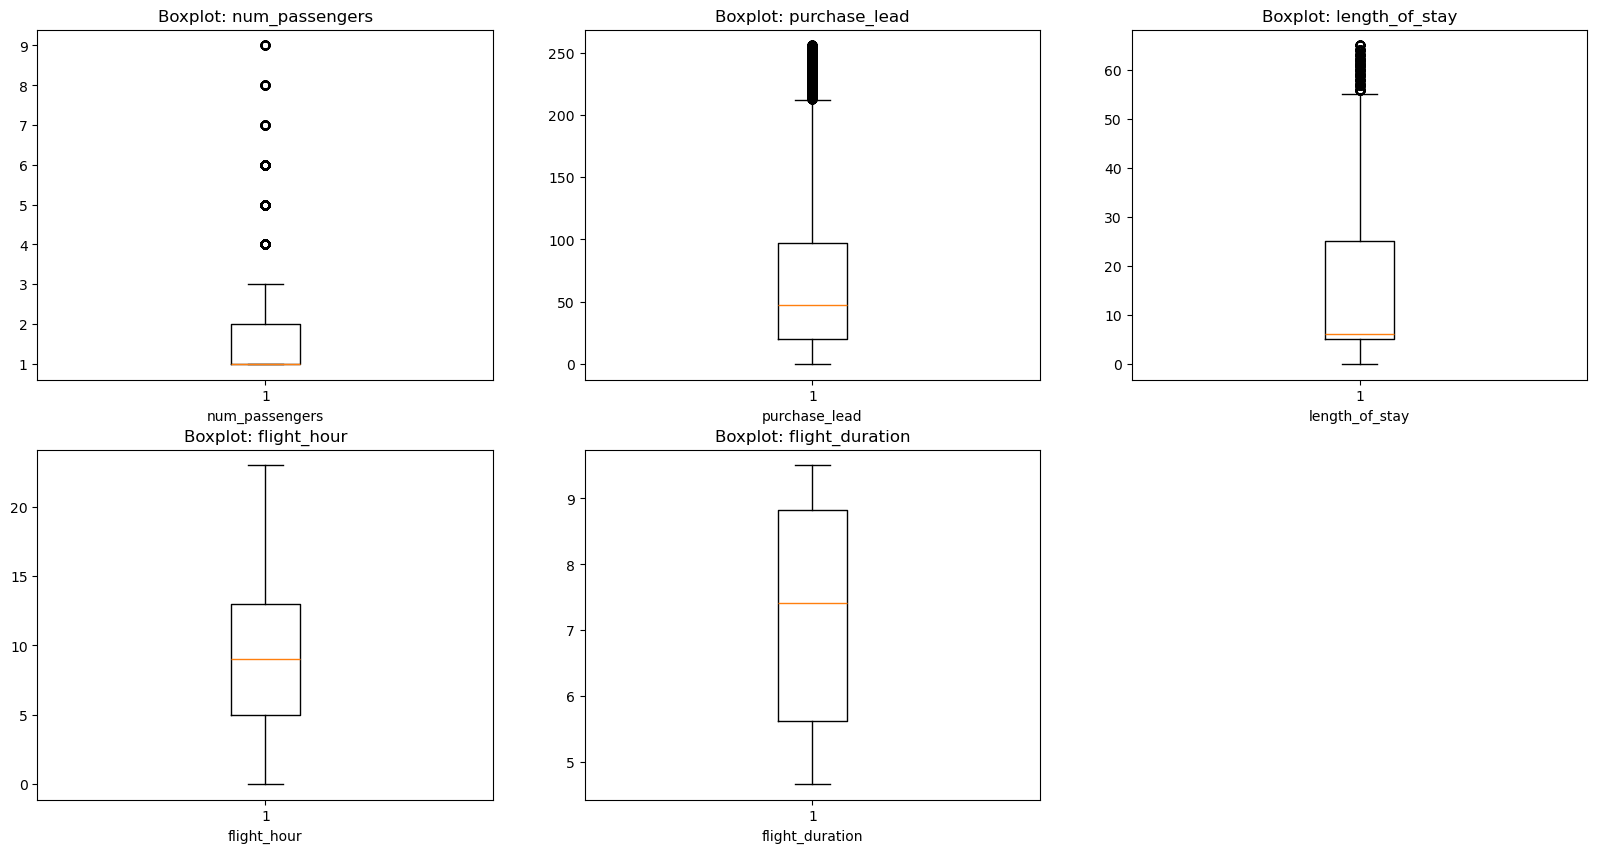

In [ ]:
numerical_cols = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration",
]

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

axs = ax.flatten()

for i, col in enumerate(numerical_cols):
    axs[i].boxplot(df[col])
    axs[i].set_xlabel(col)
    axs[i].set_title(f"Boxplot: {col}")

for i in range(len(numerical_cols), len(axs)):
    axs[i].axis("off")

Median values:
num_passengers: 1.0
purchase_lead: 47.0
length_of_stay: 6.0
flight_hour: 9.0
flight_duration: 7.42


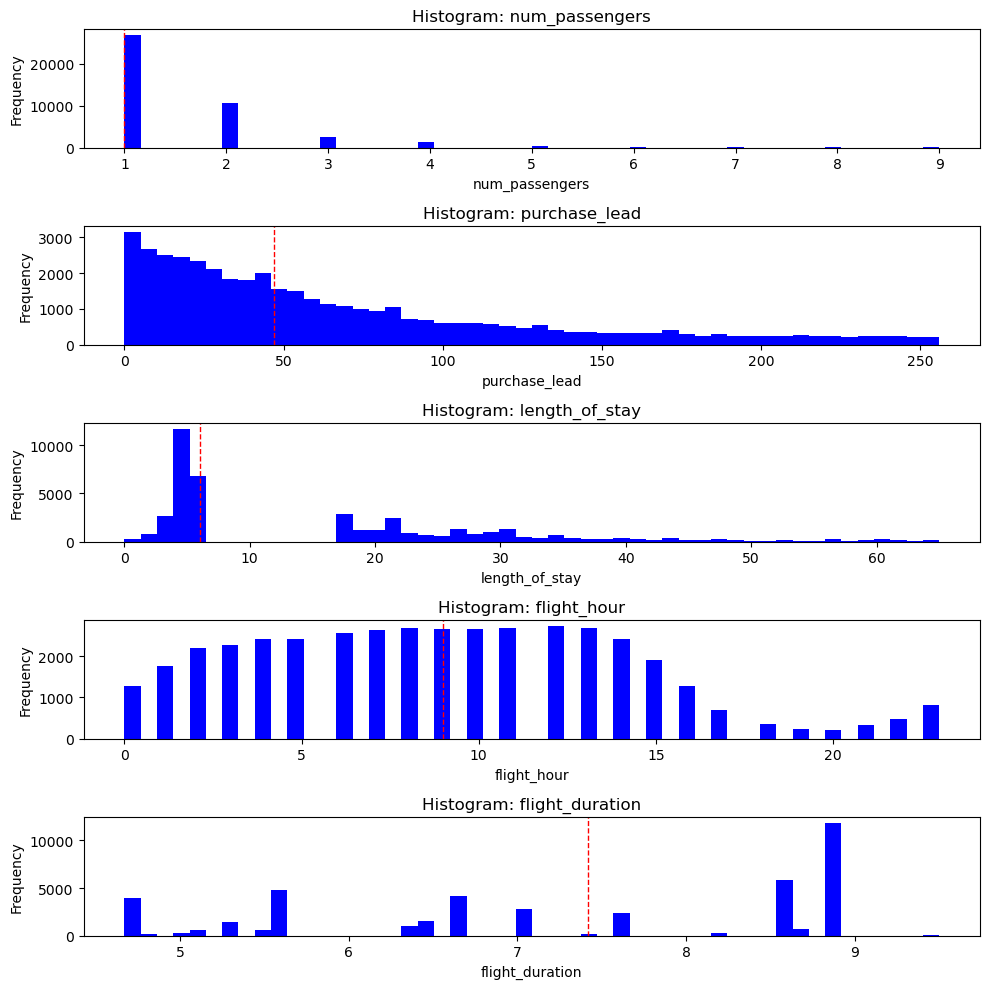

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color="blue")
    axes[i].set_title(f"Histogram: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for ax in axes:
    ax.axvline(
        df[ax.get_xlabel()].median(), color="red", linestyle="dashed", linewidth=1
    )

print("Median values:")
for col in numerical_cols:
    median_value = df[col].median()
    print(f"{col}: {median_value}")

plt.subplots_adjust(hspace=0.5)

plt.tight_layout()
plt.show()

Median values:
num_passengers: 0.0
purchase_lead: 0.18359375
length_of_stay: 0.09230769230769231
flight_hour: 0.3913043478260869
flight_duration: 0.5693581780538303


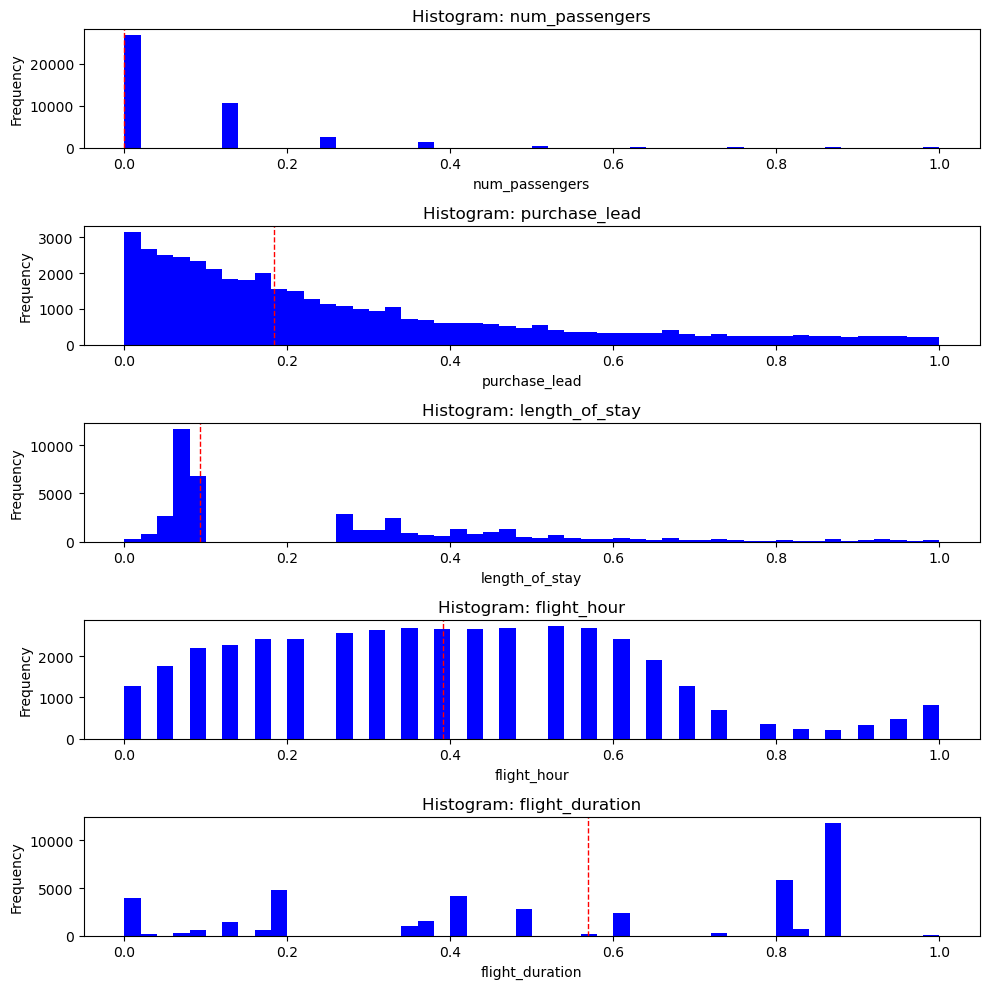

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_num = df[numerical_cols].copy()

scaler = MinMaxScaler()
df_num[numerical_cols] = scaler.fit_transform(df_num[numerical_cols])

fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_num[col], bins=50, color="blue")
    axes[i].set_title(f"Histogram: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for ax in axes:
    ax.axvline(
        df_num[ax.get_xlabel()].median(), color="red", linestyle="dashed", linewidth=1
    )

print("Median values:")
for col in numerical_cols:
    median_value = df_num[col].median()
    print(f"{col}: {median_value}")

plt.subplots_adjust(hspace=0.5)

plt.tight_layout()
plt.show()

In [ ]:
df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_id
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0,2
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0,3
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0,4
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0,5
5,1,Internet,RoundTrip,3,48,20,4,AKLDEL,New Zealand,1,0,1,5.52,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,6,PERPNH,Australia,1,0,1,5.62,0,49199
49996,1,Internet,RoundTrip,111,6,4,7,PERPNH,Australia,0,0,0,5.62,0,49200
49997,1,Internet,RoundTrip,24,6,22,6,PERPNH,Australia,0,0,1,5.62,0,49201
49998,1,Internet,RoundTrip,15,6,11,1,PERPNH,Australia,1,0,1,5.62,0,49202


In [ ]:
mean_encode = df.groupby("booking_origin")["booking_complete"].mean()

mean_encode

booking_origin
Afghanistan             0.000000
Algeria                 0.000000
Argentina               0.000000
Australia               0.047514
Austria                 0.000000
                          ...   
United Arab Emirates    0.078947
United Kingdom          0.126582
United States           0.179177
Vanuatu                 1.000000
Vietnam                 0.295681
Name: booking_complete, Length: 100, dtype: float64

In [ ]:
df["booking_origin_mean"] = df["booking_origin"].map(mean_encode)

df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_id,booking_origin_mean
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0,2,0.052566
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0,3,0.103482
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0,4,0.052566
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0,5,0.103482
5,1,Internet,RoundTrip,3,48,20,4,AKLDEL,New Zealand,1,0,1,5.52,0,6,0.052566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,6,PERPNH,Australia,1,0,1,5.62,0,49199,0.047514
49996,1,Internet,RoundTrip,111,6,4,7,PERPNH,Australia,0,0,0,5.62,0,49200,0.047514
49997,1,Internet,RoundTrip,24,6,22,6,PERPNH,Australia,0,0,1,5.62,0,49201,0.047514
49998,1,Internet,RoundTrip,15,6,11,1,PERPNH,Australia,1,0,1,5.62,0,49202,0.047514


In [ ]:
df = df.drop(["route", "booking_id", "booking_origin"], axis=1)

df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_origin_mean
1,1,Internet,RoundTrip,112,20,3,6,0,0,0,5.52,0,0.052566
2,2,Internet,RoundTrip,243,22,17,3,1,1,0,5.52,0,0.103482
3,1,Internet,RoundTrip,96,31,4,6,0,0,1,5.52,0,0.052566
4,2,Internet,RoundTrip,68,22,15,3,1,0,1,5.52,0,0.103482
5,1,Internet,RoundTrip,3,48,20,4,1,0,1,5.52,0,0.052566
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,6,1,0,1,5.62,0,0.047514
49996,1,Internet,RoundTrip,111,6,4,7,0,0,0,5.62,0,0.047514
49997,1,Internet,RoundTrip,24,6,22,6,0,0,1,5.62,0,0.047514
49998,1,Internet,RoundTrip,15,6,11,1,1,0,1,5.62,0,0.047514


In [ ]:
df["sales_channel"] = df["sales_channel"].map({"Internet": 0, "Mobile": 1})

df["trip_type"] = df["trip_type"].map({"RoundTrip": 1, "OneWay": 2, "CircleTrip": 0})

In [ ]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_origin_mean
1,1,0,1,112,20,3,6,0,0,0,5.52,0,0.052566
2,2,0,1,243,22,17,3,1,1,0,5.52,0,0.103482
3,1,0,1,96,31,4,6,0,0,1,5.52,0,0.052566
4,2,0,1,68,22,15,3,1,0,1,5.52,0,0.103482
5,1,0,1,3,48,20,4,1,0,1,5.52,0,0.052566


In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["booking_complete"], axis=1)
y = df["booking_complete"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
y_train.value_counts(normalize=True)

booking_complete
0    0.849209
1    0.150791
Name: proportion, dtype: float64

In [ ]:
from sklearn.utils import resample

df_majority = df[df.booking_complete == 0]
df_minority = df[df.booking_complete == 1]

df_minority_unsampled = resample(
    df_minority, replace=True, n_samples=len(df_majority), random_state=42
)

df_unsampled = pd.concat([df_majority, df_minority_unsampled])

df_unsampled.booking_complete.value_counts(normalize=True)

booking_complete
0    0.5
1    0.5
Name: proportion, dtype: float64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42427 entries, 1 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         42427 non-null  int64  
 1   sales_channel          42427 non-null  int64  
 2   trip_type              42427 non-null  int64  
 3   purchase_lead          42427 non-null  int64  
 4   length_of_stay         42427 non-null  int64  
 5   flight_hour            42427 non-null  int64  
 6   flight_day             42427 non-null  int64  
 7   wants_extra_baggage    42427 non-null  int64  
 8   wants_preferred_seat   42427 non-null  int64  
 9   wants_in_flight_meals  42427 non-null  int64  
 10  flight_duration        42427 non-null  float64
 11  booking_complete       42427 non-null  int64  
 12  booking_origin_mean    42427 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 4.5 MB


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, cross_val_predict

x = df.drop(columns=["booking_complete"], axis=1)
y = df["booking_complete"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(x_train, y_train)


y_pred = rf_clf.predict(x_test)
y_proba = rf_clf.predict_proba(x_test)[:, 1]

print("Accuracy (Test Set):", accuracy_score(y_test, y_pred))
print("Precision (Test Set):", precision_score(y_test, y_pred))
print("Recall (Test Set):", recall_score(y_test, y_pred))
print("F1-Score (Test Set):", f1_score(y_test, y_pred))
print("roc_auc (test-proba:", roc_auc_score(y_test, y_proba))
print(
    "roc_auc (train-proba):",
    roc_auc_score(y_train, rf_clf.predict_proba(x_train)[:, 1]),
)

Accuracy (Test Set): 0.8468065048314871
Precision (Test Set): 0.46875
Recall (Test Set): 0.09345794392523364
F1-Score (Test Set): 0.15584415584415584
roc_auc (test-proba: 0.743531510803939
roc_auc (train-proba): 0.9999998881478127


Accuracy (Test Set): 84.68%

Precision (Test Set): 46.88%

Recall (Test Set): 9.35%

F1-Score (Test Set): 15.58%

roc_auc (test-proba): 74.35%

roc_auc (train-proba): 100.00%

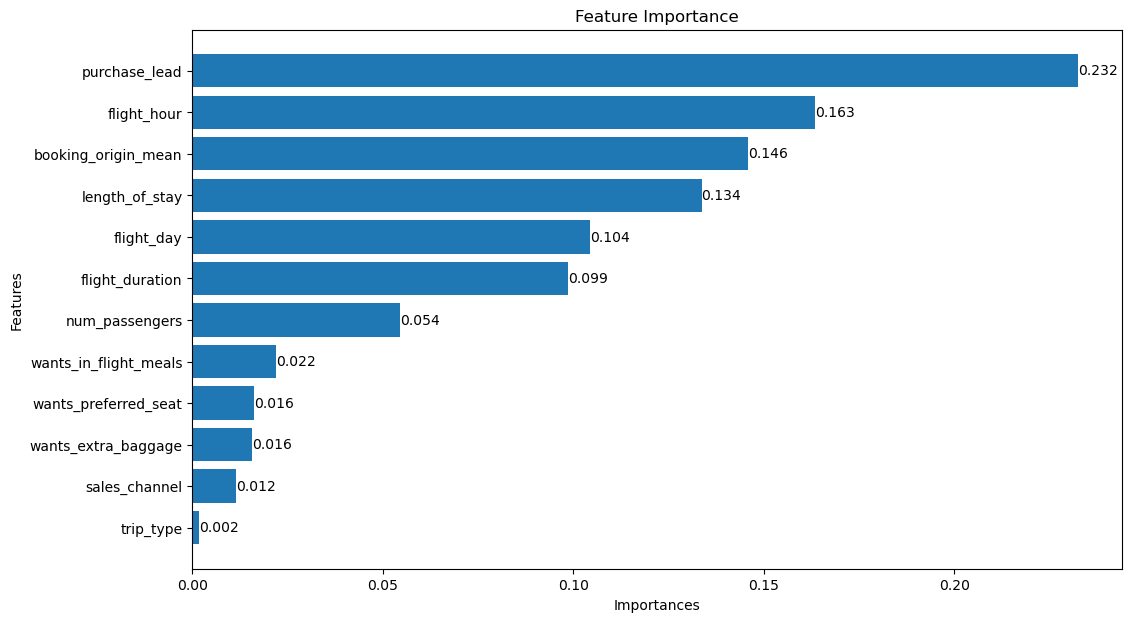

In [ ]:
importance = rf_clf.feature_importances_

indices = importance.argsort()[::-1]
sorted_features = [x.columns[i] for i in indices]
sorted_importances = [importance[i] for i in indices]

plt.figure(figsize=(12, 7))
plt.barh(range(len(sorted_importances)), sorted_importances)
plt.yticks(range(len(sorted_importances)), sorted_features)
plt.ylabel("Features")
plt.xlabel("Importances")
plt.title("Feature Importance")
plt.gca().invert_yaxis()

for i, v in enumerate(sorted_importances):
    plt.text(v, i, "{:.3f}".format(v), color="black", va="center")

plt.show()

- **purchase_lead**: The number of days between when a customer searches for a flight and when they actually purchase it. This feature could have a significant impact on the customer's buying behavior because customers who purchase flights closer to the departure date may be more likely to pay a higher price for their tickets, whereas those who purchase in advance may be more price-sensitive.

- **flight_hour**: The hour of the day when the flight is scheduled to depart. This feature could impact the customer's buying behavior, as flights departing at more convenient hours may be more in demand and therefore more expensive. On the other hand, flights departing at less convenient hours may be cheaper, but may not be as desirable to most customers.

- **booking_origin**: The origin airport for the flight. This feature could have a significant impact on the customer's buying behavior, as customers may be more likely to purchase flights from airports that are closer to their home or work locations. Additionally, certain airports may have better connections or more flight options, which could influence customer buying behavior.

- **length_of_stay**: The number of days between the flight departure date and the return date. This feature could impact the customer's buying behavior, as customers with more flexible schedules may be more willing to extend their stay, while those with tighter schedules may be more likely to book shorter trips.

- **flight_day**: The day of the week when the flight is scheduled to depart. This feature could impact the customer's buying behavior, as certain days of the week may be more popular for travel than others, leading to higher prices for flights departing on those days. Additionally, customers may be more likely to book flights departing on weekdays rather than weekends due to work or other commitments.